# Tech Challenge Fase 1 - Case NPS Preditivo 

## 1. Entendimento do Negócio

Uma empresa de e-commerce teve um grande aumento de demanda devido à evolução da área de compras online no cenário nacional. Contudo, esse crescimento acelerado trouxe desafios em manter a qualidade da experiência para o usuário final, e esses problemas são refletidos nos resultados do NPS, onde é possível perceber que há uma grande quantidade de respostas não satisfatórias.

O NPS (Net Promoter Score, ou Pontuação Líquida de Promotores) é uma importante variável de saída que resume a experiência do cliente e define sua relação de fidelidade com a empresa. Através dessa variável várias áreas podem se beneficiar:

- Suporte e Atendimento ao Cliente: podem identificar os principais problemas que causam atrito com o cliente e atuar em possíveis churn;
- Logística: podem buscar melhorias na entrega, previsão das datas de entrega, estratégias de escoamento de produtos nas diversas regiões;
- Princing: melhorar a precificação dos produtos e oferecer descontos;
- Marketing: segmentação de clientes para criação de campanhas mais assertivas.

De maneira geral, o NPS impacta também outras importantes variáveis para e-commerce:
- Recompra: clientes que deram boas notas de NPS (Promotores) normalmente confiam na empresa e realizam mais compras futuras.
- Boca a boca: Promotres costumam indicar a empresa para outras pessoas de maneira orgânica (sem custo), enquanto Detratores podem indicar a concorrência ou mesmo difamar a empresa.
- Market share: com o efeito dos Promotores ou Detratores, no longo prazo, é possível ter uma maior ou menor parcela de participação das compras totais do mercado.
- Indicadores complementares: a partir do NPS é possível derivar outras variáveis de qualidade do serviço: comparação de NPS periódico ou da concorrência (benchmark), SLA logístico (entrega no prazo x atrasados), taxa de devolução.

## 2. Definição da Target

Iniciando uma análise superficial do dataset com os resultados de NPS `../data/desafio_nps_fase_1.csv`, podemos identificar que a variável target que representa a satisfação do cliente é o **`nps_score`**. Ela precisa ser a variável target pois é a pontuação final definida pelo cliente na pesquisa de satisfação. No caso do cenário atual que estamos trabalhando, essa variável é coletada no final da experiência de uma compra.

Um risco que devemos levar em consideração é justamente o momento da coleta: final da jornada de compra. É uma pesquisa reativa em que geralmente apenas clientes insatisfeitos ou que tiveram algum tipo de problema respondem. Portanto, os dados podem estar enviesados com informações em sua maioria negativas e podem não refletir a real situação reputacional da empresa quando comparado ao todo. Ou seja, se uma pesquisa de NPS possui 500 casos e, desses, 100% são detratores, pode ser que apenas 500 casos não sejam realmente um problema se o total de compras da empresa está na casa dos milhões. Por isso, é importante ter cuidado ao realizar a análise dos dados.

## 3. Análise Exploratória dos Dados (EDA)

Vamos iniciar a EDA, verificando os dados disponíveis no dataset, compreendendo as variáveis e casos e observando a integridade do conjunto do dados disponíveis.

### Verificação das características e integridade do dataset

In [339]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('../data/desafio_nps_fase_1.csv')
df.head(10)

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9
5,6,35,Sudeste,75,50006,568.76,6,36.58,3,4,5,41.82,2,2,3,0.9,0,5,1.5
6,7,37,Sudeste,68,50007,41.29,3,99.62,6,8,3,35.83,3,3,4,1.4,0,6,0.6
7,8,60,Sul,37,50008,428.76,4,29.54,10,11,5,44.50,1,0,2,0.0,0,2,4.1
8,9,40,Sul,60,50009,121.56,3,91.95,6,6,3,24.88,2,1,9,6.2,0,3,0.8
9,10,51,Sudeste,70,50010,411.01,6,37.47,3,9,2,30.59,1,0,7,2.7,0,2,4.2


A visualização primária das características do dataset nos mostra a presença de 19 variáveis. Dessas variáveis, temos a seguinte classificação:
- qualitativas nominais:
  - custom_id, order_id, customer_region, repeat_purchase_30d
- quantitativas discretas:
  - customer_age, customer_tenure_months, items_quantity, payment_installments, delivery_time_days, delivery_delay_days, delivery_attempts, customer_service_contacts, resolution_time_days, complaints_count,
- quantitativas contínuas:
  - order_value, discount_value, freight_value, nps_score, csat_internal_score  

Essa abordagem irá facilitar nossa análise posterior, visto que cada tipo de variável suscita uma forma diferente de abordagem na análise exploratória

In [340]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

Com base nas informações apresentadas sobre o dataset, identificamos 2500 casos, sendo todos eles não nulos. Ou seja, para cada um dos casos, os dados de todas as variáveis são existentes. Como nossa abordagem inicial perpassa apenas a análise descritiva dos dados e possuímos um dataset realtivamente pequeno, optamos por não colher amostras em um primeiro momento e lidar com o dataset completo, para compreender melhor os padrões iniciais que guiarão nossas análises futuras.

In [341]:
df.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

Utilizamos o teste com .isnull()sum() para garantir a não nulidade dos dados. Como o teste isnull() retorna o booleano 'false', a soma dos retornos das variáveis igual a zero indica que não há nenhum caso de nulidade entre as variáveis. 

### Análise de dados de uma variável

In [342]:
df.describe(include='all')

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00000,2500.000000,2500,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
unique,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Sul,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,521,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1250.50000,43.396000,NaN,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600
std,721.83216,14.888487,NaN,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957
min,1.00000,18.000000,NaN,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,NaN,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000
50%,1250.50000,43.000000,NaN,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000
75%,1875.25000,56.000000,NaN,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000


Com relação aos dados de estatística descritiva das variáveis, observamos valores máximos de order_value e discount_value com uma magnitude bem mais elevada que os demais quartis dessas mesmas variáveis, o que pode indicar a presença de outliers. Trabalhar com a segmentação desses dados pode ser uma forma de amenizar essa flutuação, visto que esses dados extremos seriam incorporados em intervalos de desconto, por exemplo, em descontos acima de 30%. Percebemos tambem que para muitas variáveis numéricas, a dispersão dos dados está bastante elevada. Isso fica evidente pelos dados de desvio padrão estarem na mesma magnitude dos dados de medida central. Algumas variáveis também apresentaram média discrepante da mediana, como order_value e discount_value, o que pode indicar assimetria na distribuição.

Considerando o problema de negócio apresentado, acreditamos que os **dados logísticos e de atendimento possam ter um peso elevado sobre o nps_score**. É natural que, ao expandir os negócios, haja uma sobrecarga sobre esses setores. Tentaremos entender também **se existe algum padrão relevante de segmentação dos dados dos clientes** e **como os dados da encomenda podem impactar o NPS**, de modo a pensar em possíveis mecanismos de compensação para os clientes. Essas hipóteses baseadas puramente na observação da descrição do negócio serão analisadas durante a análise descrita.

#### Dados do cliente

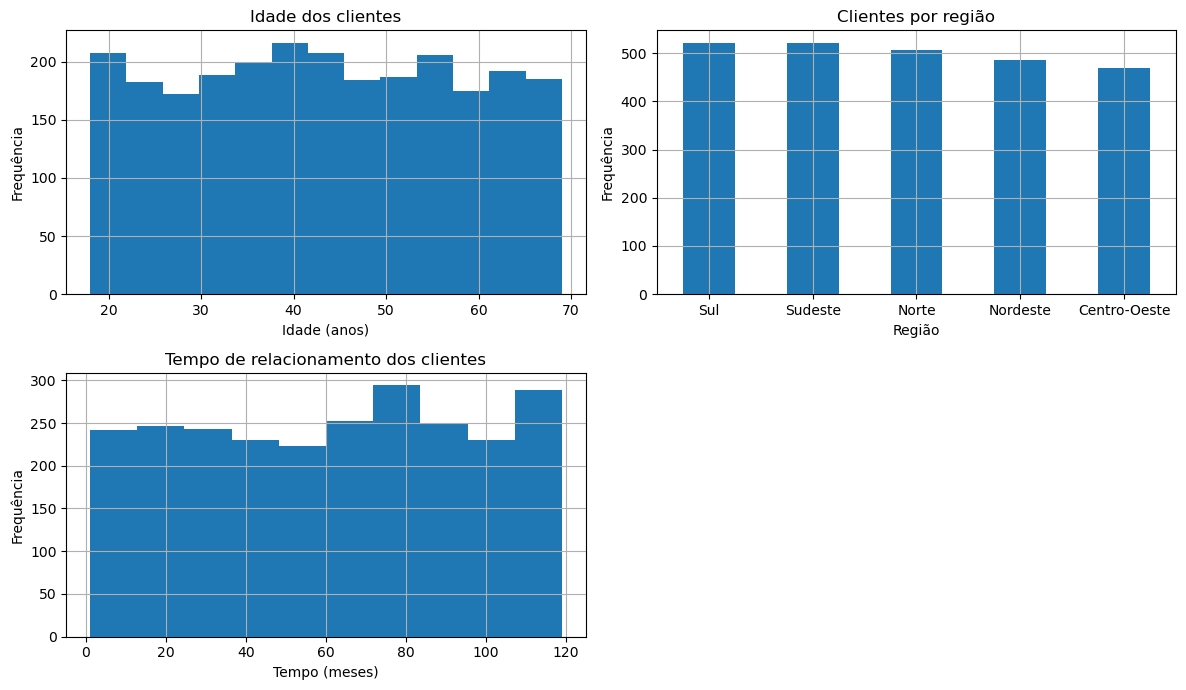

In [343]:
#Grades do plot
fig, axs = plt.subplots(2, 2, figsize=(12, 7))

# Gráfico 1, contendo o histograma dos dados de idade dos cliente. Testamos alguns bins para testar qual nos pareceria mais apresentável
df['customer_age'].hist(bins=13, ax = axs[0,0])
axs[0,0].set_title('Idade dos clientes')
axs[0,0].set_xlabel('Idade (anos)')
axs[0,0].set_ylabel('Frequência')
axs[0,0].grid(True)

# Gráfico 2, contendo a frequência por região geográfica. Utilizamos o tick_params para manter os rótulos das barras na horizontal
region_counts = df['customer_region'].value_counts().plot(kind='bar', ax = axs[0,1])
axs[0,1].set_title('Clientes por região')
axs[0,1].set_xlabel('Região')
axs[0,1].set_ylabel('Frequência')
axs[0,1].grid(True)
axs[0,1].tick_params(axis='x', rotation=0)

# Gráfico 3, com o histrograma do tempo de relacionamento em meses
df['customer_tenure_months'].hist(bins=10, ax = axs[1,0])
axs[1,0].set_title('Tempo de relacionamento dos clientes')
axs[1,0].set_xlabel('Tempo (meses)')
axs[1,0].set_ylabel('Frequência')
axs[1,0].grid(True)

axs[1,1].axis('off')
plt.tight_layout()
plt.show()

Não encontramos padrões iniciais muito relevantes nas idades. Nenhuma faixa etária especifíca nos chamou a atenção, em termos da quantidade de clientes. Em relação às regiões, a diferença entre a frequência dos clientes do Sul e do Centro-Oeste, regiões com mais e menos clientes, respectivamente, é inferior a 100 pessoas. Isso também não nos pareceu uma diferença muito relevante, em relação à quantidade total de clientes.

#### Dados da encomenda

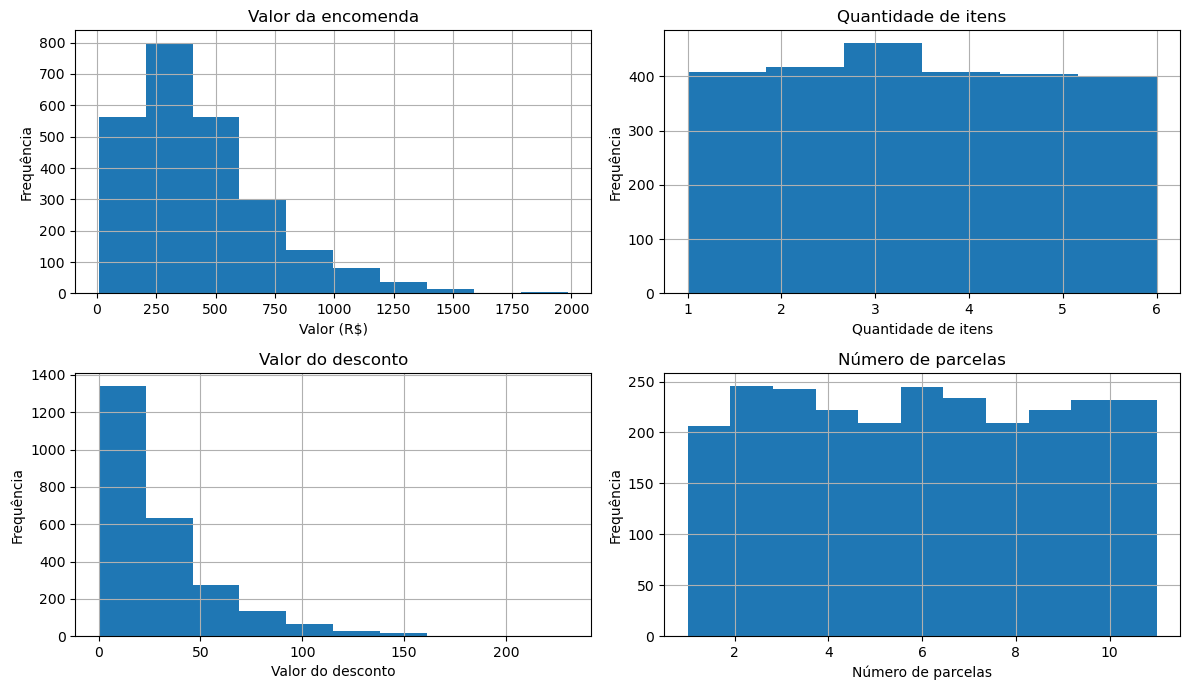

In [344]:
#Grades do plot em duas linhas e duas colunas
fig, axs = plt.subplots(2, 2, figsize=(12, 7))

# Gráfico 4, contendo o histograma dos dados de valor da encomenda. Testamos alguns bins e o 10 nos pareceu mais apresentável
df['order_value'].hist(bins=10, ax = axs[0,0])
axs[0,0].set_xlabel('Valor (R$)')
axs[0,0].set_ylabel('Frequência')
axs[0,0].set_title('Valor da encomenda')
axs[0,0].grid(True)

# Gráfico 5, contendo o histograma da quantidade de itens por compra. Por ser discreta, optamos por utilizar o valor máximo dela no número de bins
df['items_quantity'].hist(bins=6, ax = axs[0,1])
axs[0,1].set_xlabel('Quantidade de itens')
axs[0,1].set_ylabel('Frequência')
axs[0,1].set_title('Quantidade de itens')
axs[0,1].grid(True)

# Gráfico 6, contendo o histograma dos valores de desconto no valor do produto
df['discount_value'].hist(bins=10, ax = axs[1,0])
axs[1,0].set_xlabel('Valor do desconto')
axs[1,0].set_ylabel('Frequência')
axs[1,0].set_title('Valor do desconto')
axs[1,0].grid(True)

# Gráfico 7, contendo os dados de número de parcelas
df['payment_installments'].hist(bins=11, ax = axs[1,1])
axs[1,1].set_xlabel('Número de parcelas')
axs[1,1].set_ylabel('Frequência')
axs[1,1].set_title('Número de parcelas')
axs[1,1].grid(True)


plt.tight_layout()
plt.show()

A princípio, não inferimos nada de relevante sobre o número de parcelas e a quantidade de itens, visualizando apenas o histograma. Os gráficos de valor da encomenda e valor de desconto apresentam assimetria, concentrando a maior parte dos casos em valores abaixo da média. Essa distribuição corrobora os dados obtidos nos cálculos de média e mediana. Para ambas as variáveis, o valor da mediana foi inferior ao da média, indicando a assimetria observada graficamente.

#### Dados logísticos

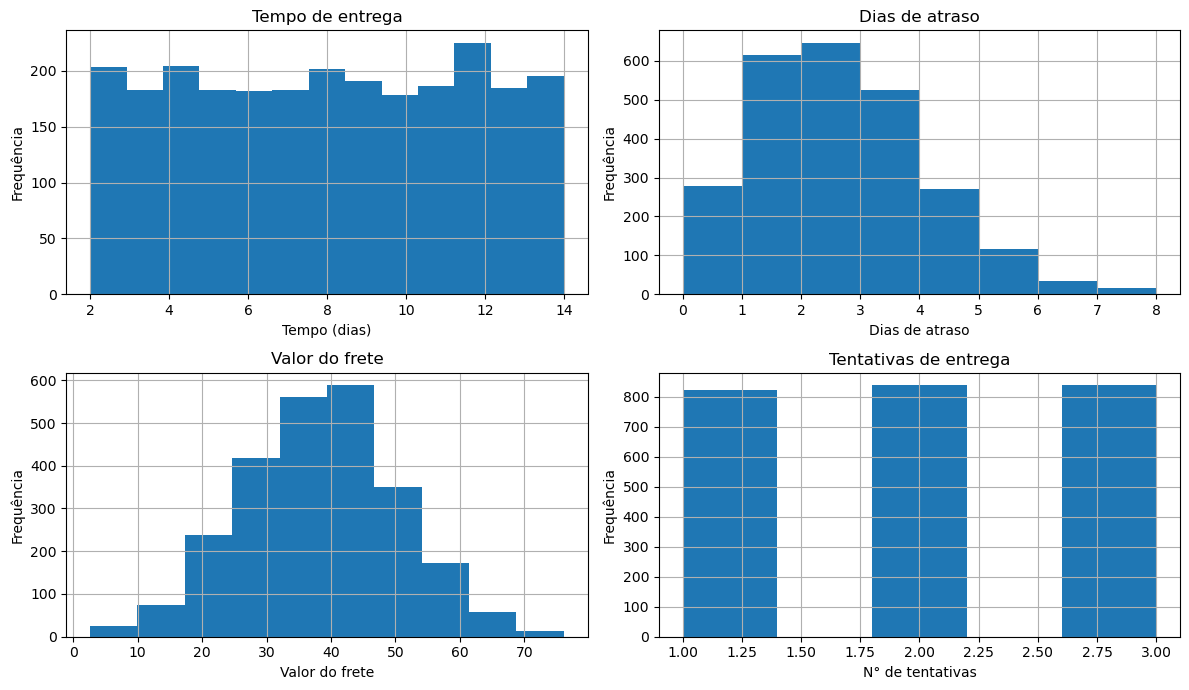

In [345]:
#Grades do plot em duas linhas e duas colunas
fig, axs = plt.subplots(2, 2, figsize=(12, 7))

# Gráfico 8, contendo o histograma do nº de dias para entrega do pedido
df['delivery_time_days'].hist(bins=13, ax = axs[0,0])
axs[0,0].set_xlabel('Tempo (dias)')
axs[0,0].set_ylabel('Frequência')
axs[0,0].set_title('Tempo de entrega')
axs[0,0].grid(True)

# Gráfico 9, contendo o histograma dos dias de atraso na entrega
df['delivery_delay_days'].hist(bins=8, ax = axs[0,1])
axs[0,1].set_xlabel('Dias de atraso')
axs[0,1].set_ylabel('Frequência')
axs[0,1].set_title('Dias de atraso')
axs[0,1].grid(True)

# Gráfico 10, contendo o histograma dos valores de frete
df['freight_value'].hist(bins=10, ax = axs[1,0])
axs[1,0].set_xlabel('Valor do frete')
axs[1,0].set_ylabel('Frequência')
axs[1,0].set_title('Valor do frete')
axs[1,0].grid(True)

# Gráfico 11, contendo o histograma do número de tentativas de entrega
df['delivery_attempts'].hist(bins=5, ax = axs[1,1])
axs[1,1].set_xlabel('N° de tentativas')
axs[1,1].set_ylabel('Frequência')
axs[1,1].set_title('Tentativas de entrega')
axs[1,1].grid(True)


plt.tight_layout()
plt.show()

In [346]:
df['delivery_attempts'].value_counts()

delivery_attempts
3    838
2    838
1    824
Name: count, dtype: int64

 O histograma do tempo de entrega nos mostra dados entre 2 e 14 dias, mas bem próximos entre si, pensando na quantidade de entregas. Não foi observado padrão de sino neste histograma. Já os histogramas de dias de atraso e valor do frete apresentam forma de sino, sendo o primeiro assimétrico, enquanto o segundo lembra uma distribuição normal. Achamos relevante o fato de que embora os dados de tempo de entrega sejam distribuídos de forma mais ou menos uniforme entre os dias, os dados de atraso se concentram mais em torno de 2 a 3 dias. Esse fato nos suscitou a ideia de no futuro buscar uma correção para os dias de entrega, como forma de amenizar os possíveis efeitos do atraso sobre o NPS. Na análise de duas variáveis, voltaremos aos dados de entrega para compreender melhor sua relação com o nps_score. O histograma de entrega mostra 3 barras quase idênticas, o que evidencia que a empresa usa o padrão de 3 tentativas antes de cancelar a entrega. Através da tabela verificamos que a soma das três tentativas foi igual a 2500, o que significa que todas as encomendas foram entregues. Nos pareceu também que esses valores de segunda e terceira tentativas foram bastante elevados. Seria mais natural para nós que os casos de entrega na primeira tentativa fossem maiores em relação aos demais. Isso pode indicar que esteja havendo um desencontro elevado entre entregador e o cliente, não por culpa do cliente, mas porque o atraso na entrega pode torná-la imprevisível para cliente que se programa para que o pacote chegue em um determinado dia e não três dias depois. Tais tentativas sucessivas podem impactar também os custos da empresa com logística, tornando-os mais elevados.

#### Dados de atendimento

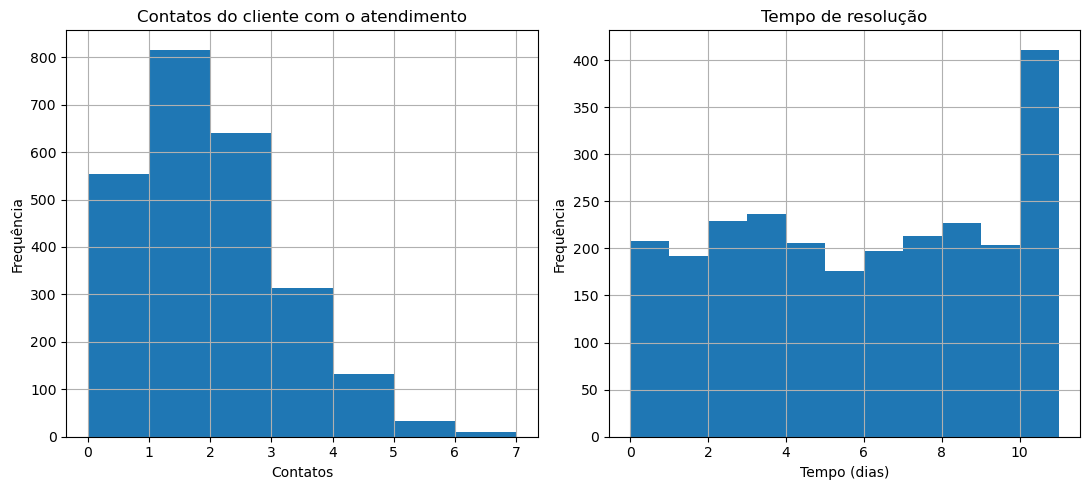

In [347]:
#Grades do plot em duas linhas e duas colunas
fig, axs = plt.subplots(1, 2, figsize=(11, 5))

# Gráfico 12, contendo o histograma do nº de contatos do cliente com o atendimento
df['customer_service_contacts'].hist(bins=7, ax = axs[0])
axs[0].set_xlabel('Contatos')
axs[0].set_ylabel('Frequência')
axs[0].set_title('Contatos do cliente com o atendimento')
axs[0].grid(True)

# Gráfico 13, contendo o histograma dos dias que demoram para a resolução das demandas dos clientes
df['resolution_time_days'].hist(bins=11, ax = axs[1])
axs[1].set_xlabel('Tempo (dias)')
axs[1].set_ylabel('Frequência')
axs[1].set_title('Tempo de resolução')
axs[1].grid(True)

plt.tight_layout()
plt.show()

Percebemos padrões de sino nos histogramas de contatos. A concentratação de dados de reclamações em torno de 4 nos mostra uma quantidade relevante de clientes insatisfeitos. O tempo de resolução elevado, com mais de 400 cliente acima de 10 dias, evidencia a dificuldade do atendimento em lidar com as insatisfações dos clientes, em um cenário de alta demanda e atrasos constantes de entrega.

#### Dados de satisfação

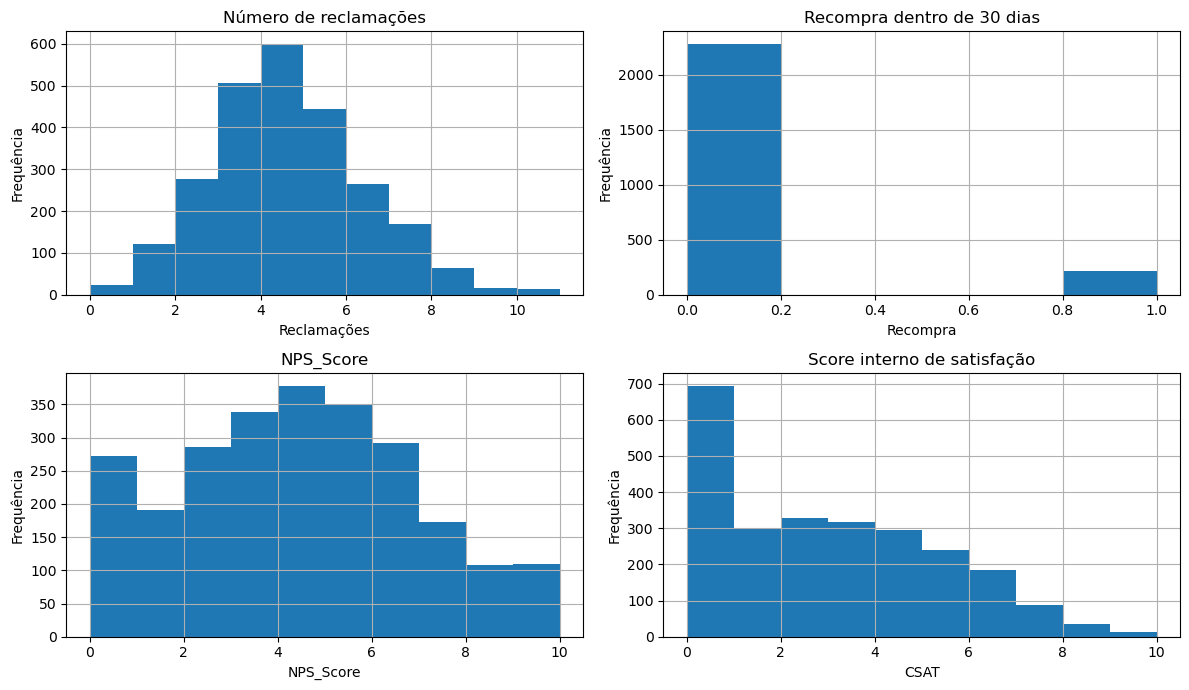

In [348]:
#Grades do plot em duas linhas e duas colunas
fig, axs = plt.subplots(2, 2, figsize=(12, 7))

# Gráfico 14, contendo o histograma do número de reclamações
df['complaints_count'].hist(bins=11, ax = axs[0,0])
axs[0,0].set_xlabel('Reclamações')
axs[0,0].set_ylabel('Frequência')
axs[0,0].set_title('Número de reclamações')
axs[0,0].grid(True)

# Gráfico 15, contendo o histograma das recompras dentro de um mês
df['repeat_purchase_30d'].hist(bins=5, ax = axs[0,1])
axs[0,1].set_xlabel('Recompra')
axs[0,1].set_ylabel('Frequência')
axs[0,1].set_title('Recompra dentro de 30 dias')
axs[0,1].grid(True)

# Gráfico 16, contendo o histograma dos NPS_Score
df['nps_score'].hist(bins=10, ax = axs[1,0])
axs[1,0].set_xlabel('NPS_Score')
axs[1,0].set_ylabel('Frequência')
axs[1,0].set_title('NPS_Score')
axs[1,0].grid(True)

# Gráfico 17, contendo o histograma dos dados de CSAT
df['csat_internal_score'].hist(bins=10, ax = axs[1,1])
axs[1,1].set_xlabel('CSAT')
axs[1,1].set_ylabel('Frequência')
axs[1,1].set_title('Score interno de satisfação')
axs[1,1].grid(True)

plt.tight_layout()
plt.show()

O histograma de número de reclamações apresenta um padrão visual parecido com uma curva normal, com forma de sino. A distribuçao dos dados de recompra apresenta uma concentração de menos de 300 pessoas entre os que recompraram. Podemos perceber no histograma do nps_score que o número de pessoas com notas 9 e 10 também foi abaixo de 300. É possível e até natural que exista uma relação entre notas altas e recompra. O histograma de CSAT mostra uma concentração elevada de casos na primeira metade do gráfico. O CSAT e o nps_score apresentaram histogramas assimétricos com medianas levemente inferiores às médias. Isso evidencia uma concentratação maior de dados em valores mais baixos. No entanto, comparando as duas variáveis, percebemos que o CSAT apresenta em média, valores mais baixos que o nps_score, com uma concentração elevada, próxima de 700, das notas entre 0 e 1. Isso pode indicar a presença de clientes com um histórico de relacionamento com a empresa, mas que demonstraram insatisfação através dos últimos pontos de contato com a mesma. Como o CSAT representa uma métrica mais imediata e setorizada do cliente em relação aos serviços e produtos da empresa, é de se esperar que ela sofra mais por conta dos resultados negativos em logística e atendimento. Isso sugere que, caso os problemas gerados pelo aumento de demanda permaneçam, isso possivelmente terá um efeito ainda mais deletério sobre o NPS.  

Na próxima etapa de análise, verificaremos o impacto das variáveis sobre o nps_score. Em especial, buscaremos relações entre os dados logísticos e de atendimento com o nps_score, para compreender como os atraso elevado e as dificuldades de resolução de problemas do cliente no atendimento, observados nos histogramas, se correlacionam com os dados de satisfação. Iremos analisar também se existe impacto dos preços dos produtos, dos descontos e dos valores de frete sobre as zonas de NPS, para entendermos se possíveis descontos podem auxiliar na diminuição de clientes detratores. Por último, buscaremos padrões de segmentação dos clientes para entendermos se trabalhar pontualmente, através de marketing, promoções ou isenções de frete, com faixas etárias ou regiões geográficas específicas pode ter impacto relevante sobre o NPS.

### Análise de dados de duas ou mais variáveis

Utilizaremos algumas segmentações pertinentes para compreender melhor a relação entre nossa variável de saída, o nps_score, e os demais grupos de variáveis. Optamos, na maior parte dos casos, pela utilização do teste ANOVA para verificar a validade da hipótese de igualdade das médias de nps_score dos segmentos, visto que o número de segmentações quase sempre foi maior que 2, o que impedia a comparação direta entre hipóteses A e B. Além disso, entendemos que essa abordagem poderia ser mais interessante para entender, em termos mais quantitativos, a relação entre as variáveis de entreda e o nps_score individual dos clientes, para o caso de utilizarmos um método de regressão posteriormente. A hipótese nula padrão foi a de que as médias do nps_score seriam iguais para as diferentes faixas de segmentação das variáveis analisadas. 

No caso particular dos dados da encomenda, utilizamos a variável order_value_total como referência para trazermos os valores de desconto e de frete para uma base de comparação mais padronizada, através da porcentagem, em vez de trabalhar com os dados absolutos. Escolhemos essa abordagem porque a percepção do cliente sobre um mesmo valor de desconto ou de frete de R$ 30,00 pode variar, a depender se o valor do pedido for de R$ 50,00 ou R$ 1000,00, por exemplo. Percebemos também que alguns casos o valor de desconto foi superior ao valor da encomenda. Isso nos evidenciou que a variável order_value já considerava o preço após a aplicação do desconto. Por esse motivo, criamos a variável order_value_total, citada anteriormente, para antes o valor bruto, antes da aplicação do desconto.

Em alguns casos, optamos pelo uso do teste qui-quadrado e pela segmentação do nps_score em detratores, neutros, juntamente com a segmentação da variável de entrada. Optamos por essa abordagem para 'diluir' possíveis outliers naturais nesses segmentos e porque no caso dos descontos, preço e frete, nosso interesse estava mais voltado para entender o impacto qualitativo dessas variáveis sobre a transformação de detratores em neutros e promotores, do que o impacto numérico sobre as médias do nps_score. 

#### Segmentação das variáveis

In [ ]:
#Cálculo do NPS global, com base nas notas individuais dos clientes
def calcula_nps(notas):
    defensores = np.sum(notas >= 9)
    detratores = np.sum(notas <= 6)
    return 100*(defensores - detratores)/len(notas)

# Função de segmentação com base na idade do cliente. Utilizamos as classificações jovem, adulto e idoso.
def calcula_faixa_etaria(anos):
  if(anos >= 60):
    return 'idoso'
  if(anos >= 30 and anos < 60):
    return 'adulto'
  return 'jovem'

#Criação da variável faixa_etaria que recebe a segmentação com base na idade dos clientes
df['faixa_etaria'] = df['customer_age'].map(calcula_faixa_etaria)


# Função para segmentar a variável de tempo de relacionamento. Optamos por segmentá-la em valores próximos aos quartis
def calcula_faixa_relacionamento(months):
  if months <= 31:
    return '[1-31]'
  if months <= 62 and months>31:
    return '[32-62]'
  if months <=91 and months > 62:
    return '[63-91]'
  return '[92-119]'

#Variável faixa_relacionamento recebe a segmentação com base no tempo de relacionamento dos clientes
df['faixa_relacionamento'] = df['customer_tenure_months'].map(calcula_faixa_relacionamento)


# Segmentação da porcentagem de desconto. Utilizamos como valores para segmentação, valores típicos de desconto por experiência
def calcula_faixa_desconto(porc):
  if porc >= 0 and porc <= 15:
    return 'desconto_baixo'
  if porc > 15 and porc <= 30:
    return 'desconto_médio'
  if porc > 30:
    return 'desconto_alto'
  
# Segmentação para porcentagem de frete. Não tínhamos uma referência comum para estabelecermos. Por isso, optamos pelos tercis da porc_frete
def calcula_faixa_frete(porc):
  if porc >= 0 and porc <= 6.72:
    return 'frete_baixo'
  if porc > 6.72 and porc <= 12.94:
    return 'frete_medio'
  if porc > 12.94:
    return 'frete_alto'

#Calculo do valor total da encomenda, sem o desconto
df['order_value_total'] = df['order_value'] + df['discount_value']

#Calculamos a porcentagem de desconto e de frete, tendo como referência o valor total da encomenda.
#O objetivo é padronizar os dados de desconto e frete, para melhorar a comparação entre clientes com diferentes valores de encomenda
df['porc_desconto'] = 100*df['discount_value']/df['order_value_total']
df['porc_frete'] = 100*df['freight_value']/df['order_value_total']

#Variáveis faixa_desconto e faixa_frete recebem as segmentações com base na porc_frete e porc_desconto
df['faixa_desconto'] = df['porc_desconto'].map(calcula_faixa_desconto)
df['faixa_frete'] = df['porc_frete'].map(calcula_faixa_frete)


# Segmentação do delivery_time_days, com base nos quartis
def calcula_tempo_entrega(days):
    if days >= 2 and days < 5:
        return '[2-4]'
    if days >=5 and days < 8:
       return '[5-7]'
    if days >= 8 and days <11:
       return '[8-10]'
    return '[11-14]'

# Variável faixa_tempo_entrega recebe as segmentações aplicadas ao delivery_time_days
df['faixa_tempo_entrega'] = df['delivery_time_days'].map(calcula_tempo_entrega)

# Segmentação do nps_score, com base nas classificações padrão de detratores, neutros e promotores
def classify_nps(score):
    if score >= 9:
        return 'promoter'
    if score >= 7:
        return 'passive'
    return 'detractor'

# Variável nps_class recebe as segmentações aplicadas sobre o nps_score
df['nps_class'] = df['nps_score'].map(classify_nps)


#Função que segmenta cliente com e sem atraso na entrega da encomenda.
def calcula_atraso(dias):
  if(dias > 0):
    return 1
  return 0

#Criação da variável atraso, que utiliza a função calcula_atraso para segmentar os clientes com e sem delay na entrega
df['atraso'] = df['delivery_delay_days'].map(calcula_atraso)


# Segmentação do customer_service_contacts
def calcula_contatos(contacts):
    if contacts == 0:
        return '0'
    if contacts == 1:
       return '1'
    if contacts == 2:
       return '2'
    if contacts == 3:
       return '3'
    if contacts >= 4:
       return '4 ou mais'

# Variável faixa_contatos recebe as segmentações aplicadas ao cutomer_service_contacts
df['faixa_contatos'] = df['customer_service_contacts'].map(calcula_contatos)


# Segmentação do resolution_time_days
def calcula_resolucao(time):
    if time >= 0 and time < 3:
        return '[0-2]'
    if time >= 3 and time < 6:
       return '[3-5]'
    if time >= 6 and time < 9:
       return '[6-8]'
    if time >=9 and time <12:
       return '[9-11]'

# Variável faixa_resolucao recebe as segmentações aplicadas ao resolution_time_days
df['faixa_resolucao'] = df['resolution_time_days'].map(calcula_resolucao)

# Segmentação do csat_internal_score
def calcula_csat(nota):
    if nota >= 0 and nota < 2:
        return '[0-1]'
    if nota >= 2 and nota < 5:
       return '[2-4]'
    if nota >= 5 and nota < 8:
       return '[5-7]'
    if nota >=8:
       return '[8-10]'

# Variável faixa_car recebe as segmentações aplicadas ao csat_internal_score
df['faixa_csat'] = df['csat_internal_score'].map(calcula_csat)

# Segmentação do complaints_count
def calcula_reclamacoes(reclamacoes):
    if reclamacoes >= 0 and reclamacoes < 2:
        return '[0-1]'
    if reclamacoes >= 2 and reclamacoes < 5:
       return '[2-4]'
    if reclamacoes >= 5 and reclamacoes < 8:
       return '[5-7]'
    if reclamacoes >=8:
       return '[8-11]'

# Variável faixa_reclamacoes recebe as segmentações aplicadas ao complaints_count
df['faixa_reclamacoes'] = df['complaints_count'].map(calcula_reclamacoes)

# Comando para solicitar que a exibição do dataset mostre todas as variáveis e não haja oclusao de nenhuma delas.
pd.set_option('display.max_columns', None)
df

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,faixa_etaria,faixa_relacionamento,order_value_total,porc_desconto,porc_frete,faixa_desconto,faixa_frete,faixa_tempo_entrega,nps_class,atraso,faixa_contatos,faixa_resolucao,faixa_csat,faixa_reclamacoes
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,idoso,[1-31],179.08,21.973420,31.008488,desconto_médio,frete_alto,[2-4],detractor,1,0,[3-5],[5-7],[2-4]
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,jovem,[1-31],468.46,2.030056,6.026128,desconto_baixo,frete_baixo,[5-7],detractor,1,0,[9-11],[0-1],[2-4]
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,adulto,[92-119],549.88,7.787154,7.454354,desconto_baixo,frete_medio,[5-7],detractor,1,4 ou mais,[3-5],[0-1],[5-7]
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,adulto,[92-119],321.77,6.085092,10.951922,desconto_baixo,frete_medio,[5-7],detractor,1,1,[9-11],[0-1],[2-4]
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,adulto,[32-62],282.43,10.399037,13.922034,desconto_baixo,frete_alto,[11-14],detractor,1,1,[0-2],[5-7],[2-4]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,51,Sul,96,52496,615.81,6,11.41,2,14,3,28.96,2,1,2,3.7,0,3,4.3,adulto,[92-119],627.22,1.819138,4.617200,desconto_baixo,frete_baixo,[11-14],detractor,1,1,[0-2],[2-4],[2-4]
2496,2497,37,Sul,89,52497,73.03,1,36.44,3,12,2,27.42,2,2,7,3.7,0,4,2.5,adulto,[63-91],109.47,33.287659,25.047958,desconto_alto,frete_alto,[11-14],detractor,1,2,[6-8],[2-4],[2-4]
2497,2498,19,Sudeste,98,52498,522.78,1,4.84,9,2,2,38.94,1,1,1,7.4,0,3,6.2,jovem,[92-119],527.62,0.917327,7.380312,desconto_baixo,frete_medio,[2-4],passive,1,1,[0-2],[5-7],[2-4]
2498,2499,41,Sul,51,52499,55.87,2,2.11,2,14,5,29.10,3,3,0,2.3,0,5,1.7,adulto,[32-62],57.98,3.639186,50.189721,desconto_baixo,frete_alto,[11-14],detractor,1,3,[0-2],[0-1],[5-7]


In [350]:
df.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,order_value_total,porc_desconto,porc_frete,atraso
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600,464.005360,8.945071,12.949803,0.889200
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957,291.581724,10.745677,13.103484,0.313947
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.600000,0.004161,0.344519,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000,247.697500,2.049002,5.698000,1.000000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000,402.035000,5.410186,9.280958,1.000000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000,608.140000,11.392114,15.637039,1.000000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000,2032.310000,79.010008,294.698795,1.000000


#### Dados de correlação

In [352]:
matriz_corr = df.drop(['customer_id','customer_region','order_id','faixa_csat','faixa_reclamacoes','nps_class','faixa_resolucao','faixa_contatos','faixa_etaria','atraso','faixa_frete','faixa_relacionamento', 'faixa_desconto', 'faixa_tempo_entrega'],axis = 1).corr()
matriz_corr

,customer_age,customer_tenure_months,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,order_value_total,porc_desconto,porc_frete
customer_age,1.000000,0.029889,0.011991,-0.004716,0.007017,-0.050824,0.022542,-0.002094,-0.015174,-0.026088,0.032706,0.005458,-0.009936,0.009017,0.008211,-0.015125,0.012620,0.022647,0.010345
customer_tenure_months,0.029889,1.000000,0.011507,-0.003566,0.015332,0.000205,-0.017653,0.001198,-0.017503,-0.026009,-0.008960,-0.005167,-0.009711,0.024008,-0.009167,-0.000267,0.012972,-0.003187,-0.038471
order_value,0.011991,0.011507,1.000000,0.003973,0.011670,0.042265,-0.021890,0.005971,-0.019107,-0.005792,0.032823,-0.014299,0.036990,0.023443,0.001893,0.000807,0.994965,-0.443039,-0.564466
items_quantity,-0.004716,-0.003566,0.003973,1.000000,0.023730,-0.002980,0.020323,-0.014567,-0.011353,-0.020238,-0.014553,0.017519,0.011468,0.012073,0.024986,-0.005639,0.006327,0.002884,-0.006302
discount_value,0.007017,0.015332,0.011670,0.023730,1.000000,0.005823,-0.012101,-0.049742,0.020587,0.026542,0.016097,-0.017247,0.025104,0.014534,0.000792,0.040063,0.111829,0.646611,-0.116613
payment_installments,-0.050824,0.000205,0.042265,-0.002980,0.005823,1.000000,-0.007901,-0.026633,-0.000634,0.023752,0.025483,0.015277,0.023718,-0.010714,-0.001881,0.001777,0.042586,-0.012337,-0.050160
delivery_time_days,0.022542,-0.017653,-0.021890,0.020323,-0.012101,-0.007901,1.000000,-0.006589,-0.017541,-0.019562,0.007706,0.021217,0.000925,0.006094,-0.008998,-0.024835,-0.022967,-0.013683,0.010398
delivery_delay_days,-0.002094,0.001198,0.005971,-0.014567,-0.049742,-0.026633,-0.006589,1.000000,0.003779,0.005189,-0.024167,-0.015297,-0.597260,-0.304014,0.190225,-0.459051,0.000948,-0.035769,-0.005335
freight_value,-0.015174,-0.017503,-0.019107,-0.011353,0.020587,-0.000634,-0.017541,0.003779,1.000000,0.004010,0.024790,-0.008003,-0.041087,-0.025603,0.022673,-0.014962,-0.016925,-0.009976,0.293012
delivery_attempts,-0.026088,-0.026009,-0.005792,-0.020238,0.026542,0.023752,-0.019562,0.005189,0.004010,1.000000,-0.012063,0.014928,0.027680,0.013527,-0.006905,-0.004514,-0.003096,0.015558,-0.000188


Os **dados dos clientes** não apresentaram correlação linear relevante com nenhuma outra variável. Além disso, a customer_region. por ser categórica, não pode sequer participar da análise de correlação. Como queremos testar a possibilidade segmentação dos dados do cliente para ações sobre públicos específicos e a correlação de Pearson detecta apenas correlações lineares, iremos nos aprofundar mais nessas variáveis para verificarmos outras possibilidades de interação com o nps_score.

Os **dados da encomenda** também não apresentaram valores de correlação relevantes, com exceção da order_value e discount_value. No entanto, é natural que essas variáveis apresentem correlação, já que as variáveis que demonstraram interação com elas são variáveis dependentes dessas duas, ou seja, são funções dessas variáveis que nós mesmos definimos na etapa de segmentação. Não nos aprofundaremos muito nas variáveis payment_installments e items_quantity, por serem variáveis sem correlação relevante com nenhuma outra variável e variáveis de escolha do cliente, o que dificulta sua manipulação em possíveis estratégias de negócio.

Em relação aos **dados logísticos**, encontramos padrões interessantes. A freight_value passa pela mesma discussão que fizemos sobre as variáveis da encomenda. Possui correlação apenas com sua variável dependente, a porc_frete, o que não é pertinente à nossa análise. O número de tentativas de entrega não apresenta correlação relevante com nenhuma outra variável. É curioso, no entanto, observar que o delivery_delay_days possui correlação relevante com todos os dados de satisfação, sendo positiva com o número de reclamações, ou seja, as duas variáveis crescer juntas, e negativo em relação à recompra, CSAT e nps_score, reduzindo os valores de satisfação com o aumento do atraso. Isso mostra que o atraso nas entregas pode ter um efeito significativo sobre a satisfação do cliente. Outro dado relevante é que o delivery_time_days não parece ter relação com nenhuma outra variável. Em especial, não afeta a satisfação do cliente. Isso é importante porque reforça nossa ideia de que estender o prazo de entrega em alguns dias, em especial 3 ou 4 dias por serem próximos da média da distribuição da variável de atraso, antes de informá-lo para o cliente, pode ter um efeito significativo sobre o aumento do nps_score e sobre a diminuição de detratores. Seria uma mudança sem custos relevantes, mas com potencial de causar um impacto positivo elevado sobre a satisfação do cliente, visto que a percepção sobre o atraso impacta muito mais o cliente que do o tempo previsto para a entrega.

Agora iremos nos debruçar sobre os **dados do atendimento**. Consideramos que seria bem provável, pelas informações do negócio, que o atendimento tivesse papel relevante sobre a satisfação do cliente em um cenário de expansão acelarada dos negócios. E, de fato, a matriz de correlação nos mostra que o customer_service_contacts correlação elevada com os dados de satifação e apenas com eles. Entre esse grupo de variáveis, a que apresentou maior correlação com o número de contatos foi o número de reclamações. Entendemos isso como uma relação natural, visto que a reclamação exige contato com o atendimento. Quanto ao resolution_time_days, ele possui com com todas os dados de satisfação, mas, principalmente, com o CSAT. O CSAT é uma variável que resume a satisfação do cliente com o atendimento e com produto, através de perguntas pontuais ao final dos atendimentos e da compra. Por esse motivo, é de se esperar que ela esteja diretamente relacionada com a visão do cliente de que o atendimento demorou para resolver sua demanda, ou a tratar seu protocolo.

Os resultados relativos aos **dados de satisfação** são cruciais para o entendimento do problema de negócio. O nps_score está correlacionado a diversas variáveis, como o delivery_delay_days, customer_service_contacts, resolution_time_days, repeat_purchase_30d, complaints_count e csat_internal_score. A princípio, não vemos necessidade de nos debruçarmos sobre a recompra, visto que é um dado colhido *a posteriori*. De maneira geral, nossa desconfiança sobre o impacto da logística e do atendimento sobre o nps_score parece se confirmar. Além disso, por óbvio, as demais variáveis do próprio segmento de dados de satifação possui impacto relevante sobre o nps_score. Algo importante a se notar é que o nps_score possui pesos relativamente parecidos entre o atraso na entrega, o CSAT e a recompra. Já o CSAT, embora possua correlação com as mesmas variáveis que o nps_score, possui correlação mais elevada com o tempo de resolução, o que separa bem a natureza do CSAT, relativa ao atendimento e à avaliação mais local, com o nps_score, mais abrangente e global em termos da contribuição das variáveis.

Por último, temos o conjunto de variáveis criadas posteriormente, a order_value_total, porc_desconto e porc_frete. A matriz de correlação nos mostra que essas variáveis possuem relação apenas entre si e com as variáveis que as compõem. Tínhamos a esperança de que as mesmas, em especial a porcetagem de desconto, possuíssem algum nível de correlação com as variáveis de satisfação. Embora não apresentem, iremos verificar na próxima etapa de análise se a segmentação apresenta alguma relevância sobre o NPS ou se há alguma relação não linear que escape à correlação de Pearson, mas apareça nos testes de hipótese.


#### Dados do cliente x nps_score

Iremos verificar primeiro a frequência de cada segmento das variáveis do grupamento 'dados do cliente'. O objetivo é quantificar o n em cada um dos segmentos e verificar se a ANOVA pode ser utilizada, com base no Teorema do Limite Central.

In [ ]:
df['faixa_etaria'].value_counts()

faixa_etaria
adulto    1476
jovem      561
idoso      463
Name: count, dtype: int64

In [ ]:
df['customer_region'].value_counts()

customer_region
Sul             521
Sudeste         520
Norte           506
Nordeste        485
Centro-Oeste    468
Name: count, dtype: int64

In [ ]:
df['faixa_relacionamento'].value_counts()

faixa_relacionamento
[63-91]     633
[32-62]     628
[1-31]      627
[92-119]    612
Name: count, dtype: int64

Vimos que todas as segmentações possuem n elevado. Isso significa que o Teorema do Limite Central garante a validade da ANOVA para os casos analisados. Agora verificaremos os valores médios de nps_score para as segmentações dos dados dos clientes.

In [ ]:
df.groupby('faixa_etaria')['nps_score'].mean().sort_values(ascending=True) 

faixa_etaria
adulto    4.285637
idoso     4.474730
jovem     4.543850
Name: nps_score, dtype: float64

In [ ]:
df.groupby('customer_region')['nps_score'].mean().sort_values(ascending=True) 

customer_region
Centro-Oeste    4.209829
Sudeste         4.373846
Norte           4.382609
Nordeste        4.421649
Sul             4.490979
Name: nps_score, dtype: float64

In [ ]:
df.groupby('faixa_relacionamento')['nps_score'].mean().sort_values(ascending=True) 

faixa_relacionamento
[92-119]    4.341013
[63-91]     4.367773
[32-62]     4.399522
[1-31]      4.405263
Name: nps_score, dtype: float64

As médias do nps_score das segmentações, para as três variáveis analisadas, apresentaram valores próximos. Para testar se a diferença entre esses valores é estatisticamente relevante, aplicaremos o teste ANOVA.

In [ ]:
# Cálculo do nps_score médio para as segmentações da variável customer_age, contidas em faixa_etaria
faixa_jovem = df[df['faixa_etaria']=='jovem']['nps_score']
faixa_adulto = df[df['faixa_etaria']=='adulto']['nps_score']
faixa_idoso = df[df['faixa_etaria']=='idoso']['nps_score']

#Aplicação do teste ANOVA
f_statistic, p_value = stats.f_oneway(faixa_jovem, faixa_adulto,faixa_adulto)

#Apresentação de F e do p-valor
print('Valor F: ',f_statistic)
print('p-valor: ', p_value)

Valor F:  2.480416299100549
p-valor:  0.08385508824156582


In [ ]:
nps_Centro_Oeste = df[df['customer_region']=='Centro-Oeste']['nps_score']
nps_Sudeste = df[df['customer_region']=='Sudeste']['nps_score']
nps_Norte = df[df['customer_region']=='Norte']['nps_score']
nps_Nordeste = df[df['customer_region']=='Nordeste']['nps_score']
nps_Sul = df[df['customer_region']=='Sul']['nps_score']

f_statistic, p_value = stats.f_oneway(nps_Centro_Oeste, nps_Sudeste, nps_Norte, nps_Nordeste, nps_Sul)
print('Valor F: ',f_statistic)
print('p-valor: ', p_value)

Valor F:  0.8261444261623749
p-valor:  0.5083439586659979


In [ ]:
nps_relacionamento_1_31 = df[df['faixa_relacionamento']=='[1-31]']['nps_score']
nps_relacionamento_32_62 = df[df['faixa_relacionamento']=='[32-62]']['nps_score']
nps_relacionamento_63_91 = df[df['faixa_relacionamento']=='[63-91]']['nps_score']
nps_relacionamento_92_119 = df[df['faixa_relacionamento']=='[92-119]']['nps_score']

f_statistic, p_value = stats.f_oneway(nps_relacionamento_1_31, nps_relacionamento_32_62, nps_relacionamento_63_91, nps_relacionamento_92_119)
print('Valor F: ',f_statistic)
print('p-valor: ', p_value)

Valor F:  0.0876896368870239
p-valor:  0.9668107046110681


Nos três casos, os p-valores obtidos foram superiores a 0,05. Isso significa que a hipótese nula de igualdade das médias do nps_score para as diferentes segmentações não pode ser rejeitada. O que implica dizer que não há evidência estatística de que as médias de nps_score variem para nenhuma das variáveis analisadas, o que demonstra que, para as segmentações escolhidas, o impacto da veriação dos dados do cliente não é relevante para o NPS. Com isso, respondemos uma das hipóteses de negócio pensadas durante a análise primária dos dados e do negócio. **Não nos parece plausível trabalhar com a segmentação das características dos clientes**, para dar foco à faixa etárias, região ou clientes com mais tempo de relacionamento. **Essa abordagem não possui impacto relevante sobre o NPS**, em comparação com uma abordagem mais generalista, em termos dos dados dos clientes.

#### Dados de desconto e frete x NPS

Levando em conta as variáveis que compõem os dados da encomenda, optamos por não avaliar items_quantity e payment_installments, pelo fato dessas variáveis não apresentarem correlação relavante com o nps_score, serem de escolha do cliente e não serem manejáveis para pensarmos em mudanças nas mesmas que possam impactar o nps_score. Portanto, nos dedicaremos ao desconto e ao valor do frete. Optamos por analisar o frete junto com o desconto, embora ele tenha sido agrupado previamente entre as variáveis logísticas, por acharmos que os efeitos do desconto e da isenção do frete podem ser parecidos sobre o nps_score e a técnica de avaliação utilizada será a mesma para ambas as variáveis. Nosso objetivo ao analisá-las é compreender se podemos usar o desconto ou o frete grátis como uma ferramenta para remediar a quantidade de detratores da empresa. Como não temos casos com frete igual a 0, optamos por padronizá-lo como porcentagem em relação ao valor total da encomenda e segmentá-lo, para entender de forma geral sobre seu impacto no NPS. Por esse motivo também, entendemos que faz mais sentido analisar o nps de forma qualitativa, visto que nosso interesse é compreender a relação entre o desconto ou o frete e a proporção entre detratores e promotores, para eventualmente, utilizar o desconto e a isenção do frete como formas de converter detratores em neutros ou promotores. Do ponto de vista da visão do público em relação à empresa, o NPS não é uma nota média, mas a relação porcentual entre promotores e detratores (%promotores - %detratores). Por isso, escolhemos segmentar ambas as variáveis e realizar o teste qui-quadrado, já que nos interessa mais saber se o desconto converte o cliente do que entender se existe correlação entre essas variáveis, ou se há impacto quantitativo sobre o nps_score.

In [ ]:
# Criamos a tabela de contigência com base nas nossas variáveis previamente segmentadas
tabela_contingencia = pd.crosstab(df['faixa_desconto'], df["nps_class"])

# Execução do teste qui-quadrado
chi2, p_valor, dof, esperados = stats.chi2_contingency(tabela_contingencia)

print('O seu p-value é: ', p_valor)

O seu p-value é:  0.8901117162536082


In [ ]:
# Criamos a tabela de contigência com base nas nossas variáveis previamente segmentadas
tabela_contingencia = pd.crosstab(df['faixa_frete'], df["nps_class"])

# Execução do teste qui-quadrado
chi2, p_valor, dof, esperados = stats.chi2_contingency(tabela_contingencia)

print('O seu p-value é: ', p_valor)

O seu p-value é:  0.16915704544435314


O p-valor, tanto para o qui-quadrado da faixa de desconto quanto para a faixa do frete, foi superior a 0,05. Por esse motivo, a hipótese nula não pode ser rejeitada e assumimos que tais variáveis não afetam a proporção entre detratores e promotores. Sendo assim, **não é possível utilizar descontos ou frete grátis como forma de converter clientes detratores em neutros ou promotores**.

#### Dados logísticos x nps_score 

##### Tempo de entrega e número de tentativas de entrega

In [ ]:
df['faixa_tempo_entrega'].value_counts()

faixa_tempo_entrega
[11-14]    791
[2-4]      590
[8-10]     571
[5-7]      548
Name: count, dtype: int64

In [ ]:
df['delivery_attempts'].value_counts()

delivery_attempts
3    838
2    838
1    824
Name: count, dtype: int64

Os dados de n para todos os segmentos, em ambas as variáveis, foram superiores a 500. Isso mostra que a ANOVA pode ser utiliza sem problemas, pelo Teorema do Limite Central.

In [ ]:
df.groupby('faixa_tempo_entrega')['nps_score'].mean().sort_values(ascending=True) 

faixa_tempo_entrega
[11-14]    4.305815
[2-4]      4.317627
[8-10]     4.456567
[5-7]      4.468066
Name: nps_score, dtype: float64

In [ ]:
df.groupby('delivery_attempts')['nps_score'].mean().sort_values(ascending=True) 

delivery_attempts
2    4.259905
1    4.353034
3    4.522434
Name: nps_score, dtype: float64

As médias encontradas também não diferem tanto entre si e não existe um padrão de diminuição, com base no aumento do tempo ou das tentativas de entrega. 

In [ ]:
nps_tempo_entrega_2_4 = df[df['faixa_tempo_entrega']=='[2-4]']['nps_score']
nps_tempo_entrega_5_7 = df[df['faixa_tempo_entrega']=='[5-7]']['nps_score']
nps_tempo_entrega_8_10 = df[df['faixa_tempo_entrega']=='[8-10]']['nps_score']
nps_tempo_entrega_11_14 = df[df['faixa_tempo_entrega']=='[11-14]']['nps_score']


f_statistic, p_value = stats.f_oneway(nps_tempo_entrega_2_4, nps_tempo_entrega_5_7, nps_tempo_entrega_8_10, nps_tempo_entrega_11_14)
print('Valor F: ',f_statistic)
print('p-valor: ', p_value)

Valor F:  0.753127256848492
p-valor:  0.5204573069412052


In [ ]:
nps_tentativas_1 = df[df['delivery_attempts']==1]['nps_score']
nps_tentativas_2 = df[df['delivery_attempts']==2]['nps_score']
nps_tentativas_3 = df[df['delivery_attempts']==3]['nps_score']

f_statistic, p_value = stats.f_oneway(nps_tentativas_1, nps_tentativas_2, nps_tentativas_3)
print('Valor F: ',f_statistic)
print('p-valor: ', p_value)

Valor F:  2.3577790088537145
p-valor:  0.09484080901696629


Como esperado, pelo fato do p-valor encontrado ser maior que 0.05 nos dois casos, não há evidência estatística de impacto da variação do tempo de entrega ou do número de tentativas de entrega sobre a média dos nps_score dos segmentos. Embora não tenhamos encontrado relavância do número de entregas sobre o nps_score, entendemos que seja relevante buscar formas de reduzir o número de tentativas, visto que tentativas sucessivas podem impactar o custo da empresa com logística. Para tal, entendemos que seja fundamental evitar os atrasos na entrega, para que o cliente possa se planejar para receber a encomenda no dia combinado.

##### Atraso na entrega

Como sabemos que o delivery_delay_days seja talvez a variável de entrada mais relevante do nosso dataset, iremos nos atentar também a respeito do seu efeito sobre o cálculo global do NPS para cada dia de atraso. Utilizamos a fórmula %Promotores - %Detratores, para cada dia de atraso.

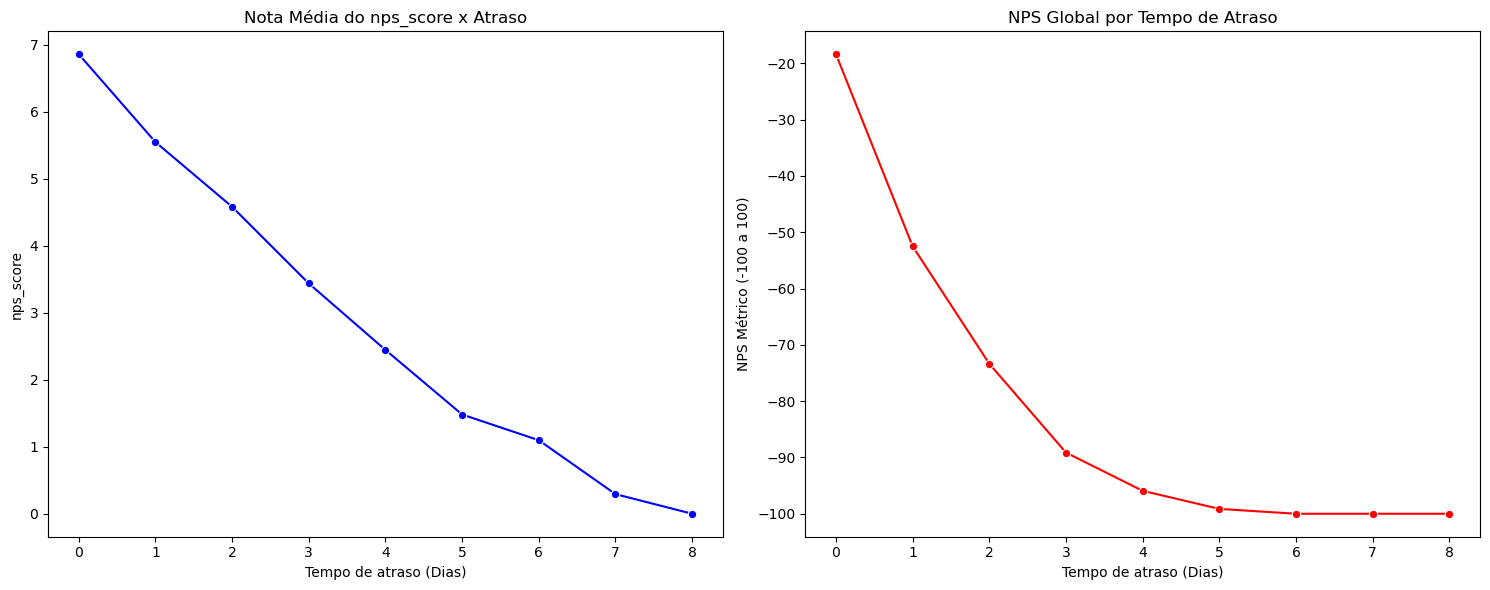

In [ ]:
# Cálculo das médias de nps_score em relação ao delivery_delay_days
nps_score_media = df.groupby('delivery_delay_days')['nps_score'].mean().reset_index()

# Cálculo do nota de NPS global em relação ao delivery_delay_days
nps_global = df.groupby('delivery_delay_days')['nps_score'].apply(calcula_nps).reset_index()

# Exibição lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# GRÁFICO 1: nps_score médio
sns.lineplot(
    data=nps_score_media, 
    x='delivery_delay_days', 
    y='nps_score', 
    marker='o', 
    color='blue', 
    ax=axes[0]
)
axes[0].set_title('Nota Média do nps_score x Atraso')
axes[0].set_xlabel('Tempo de atraso (Dias)')
axes[0].set_ylabel('nps_score')
axes[0].grid(True, alpha=0.0)

# GRÁFICO 2: NPS Global
sns.lineplot(
    data=nps_global, 
    x='delivery_delay_days', 
    y='nps_score',
    marker='o', 
    color='red', 
    ax=axes[1]
)
axes[1].set_title('NPS Global por Tempo de Atraso')
axes[1].set_xlabel('Tempo de atraso (Dias)')
axes[1].set_ylabel('NPS Métrico (-100 a 100)')
axes[1].grid(True, alpha=0.0)

plt.tight_layout()
plt.show()


Visualmente surge uma diferença interessante entre os dados. Ao considerarmos a média do nps_score, percebemos um padrão mais linear. Já para o caso do NPS global, que desconsidera apenas as faixas dos dados (0-6, 7-9 e 9-10) e não seus valores absolutos, o padrão obtido foi não linear. Uma justificativa para isso é a de que à medida em que o atraso aumenta, o número de notas 7-10 diminui drasticamente. Sendo assim, passa a não fazer diferença os valores absolutos das notas ou a média delas, caso eles sejam menores que 7. Em qualquer conjunto de dados em que o número de notas acima de 7 tenda a zero, o valor do NPS global tenderá a -100, como visto no gráfico para o valor de tendência no eixo y quando o tempo de atraso passa de 5 dias.

Como a correlação entre o nps_score e o atraso na entrega foi superior, em módulo, a 0,5 e o dataset possui um n elevado, o padrão gráfico nos parece bastante convicente para assumirmos que o tempo de atraso afeta drasticamente o NPS. Apenas a nível de confirmação, calcularemos o p-valor da correlação de Pearson, para demonstrarmos que a correlação apresentada é estatisticamente relevante (p < 0,05).

In [ ]:
# 1. Cálculo utilizando PEARSON (Mede relação linear em linha reta)
r_pearson, p_valor = stats.pearsonr(df['delivery_delay_days'], df['nps_score'])

print('Coeficiente de Pearson: ', r_pearson)
print('p-valor: ',p_valor)

Coeficiente de Pearson:  -0.5972599425164117
p-valor:  1.3144943648011457e-241


In [ ]:
print('O NPS com base nos dados completos do dataset é: ',calcula_nps(df['nps_score']))

O NPS com base nos dados completos do dataset é:  -69.64


O p-valor encontrado, da ordem de 10^(-241), não deixa dúvida de que a variável delivery_delay_days tem um impacto relevante sobre o nps_score. Ao compararmos o valor do NPS com base nos dados completos do nosso dataset, de -69.64, com o NPS considerando os casos sem delay, acima de -20, compreendemos que o trabalho sobre a percepção do cliente sobre o atraso na entrega tem um papel fundamental para elevar a satisfação dos clientes. Essa talvez seja a informação central de toda a análise exploratória de dados.

#### Dados de atendimento x nps_score 

Primeiro iremos verificar o as variáveis faixa_contatos e faixa_resolução, correspondentes às segmentações das variáveis customer_service_contacts e resolution_time_days. Ambas possuem correlação relevante em relação ao nps_score.

In [ ]:
df['faixa_contatos'].value_counts()

faixa_contatos
1            816
2            640
0            554
3            314
4 ou mais    176
Name: count, dtype: int64

In [ ]:
df['faixa_resolucao'].value_counts()

faixa_resolucao
[6-8]     637
[0-2]     629
[3-5]     619
[9-11]    615
Name: count, dtype: int64

As segmentações do número de contatos e do tempo de resolução possuem maior que 150, o que assegura a utilização do teste ANOVA.

In [ ]:
df.groupby('faixa_contatos')['nps_score'].mean().sort_values(ascending=True) 

faixa_contatos
4 ou mais    2.473295
3            3.201911
2            4.116406
1            4.657108
0            5.543502
Name: nps_score, dtype: float64

In [ ]:
df.groupby('faixa_resolucao')['nps_score'].mean().sort_values(ascending=True) 

faixa_resolucao
[9-11]    3.781789
[6-8]     4.175196
[3-5]     4.507916
[0-2]     5.040859
Name: nps_score, dtype: float64

Ambas as variáveis aparentam ter variações da média do nps_score númericamente relevantes. No entanto, precisamos realizar os testes de hipótese para determinar se do ponto de vista estatístico, podemos afirmar que a média de fato varia com os segmentos.

In [ ]:
nps_contatos_0 = df[df['faixa_contatos']=='0']['nps_score']
nps_contatos_1 = df[df['faixa_contatos']=='1']['nps_score']
nps_contatos_2 = df[df['faixa_contatos']=='2']['nps_score']
nps_contatos_3 = df[df['faixa_contatos']=='3']['nps_score']
nps_contatos_4_ou_mais = df[df['faixa_contatos']=='4 ou mais']['nps_score']



f_statistic, p_value = stats.f_oneway(nps_contatos_0, nps_contatos_1, nps_contatos_2, nps_contatos_3, nps_contatos_4_ou_mais)
print('Valor F: ',f_statistic)
print('p-valor: ', p_value)

Valor F:  87.26956263449728
p-valor:  1.7429599152469256e-69


In [ ]:
nps_resolucao_0_2 = df[df['faixa_resolucao']=='[0-2]']['nps_score']
nps_resolucao_3_5 = df[df['faixa_resolucao']=='[3-5]']['nps_score']
nps_resolucao_6_8 = df[df['faixa_resolucao']=='[6-8]']['nps_score']
nps_resolucao_9_11 = df[df['faixa_resolucao']=='[9-11]']['nps_score']



f_statistic, p_value = stats.f_oneway(nps_resolucao_0_2, nps_resolucao_3_5, nps_resolucao_6_8, nps_resolucao_9_11)
print('Valor F: ',f_statistic)
print('p-valor: ', p_value)

Valor F:  29.070675808844904
p-valor:  1.800045849607339e-18


Para as duas variáveis de atendimento encontramos p-valor menor que 0,05, evidenciando que a hipóteses nula de que as médias são iguais para todos os segmentos deve ser abandonada. Além disso, a comparação entre o Valor F dos dois teste, mostra que o número de contatos que o cliente tem com o atendimento tem um peso maior sobre a variação da média do NPS do que o tempo de resolução das demandas do cliente.

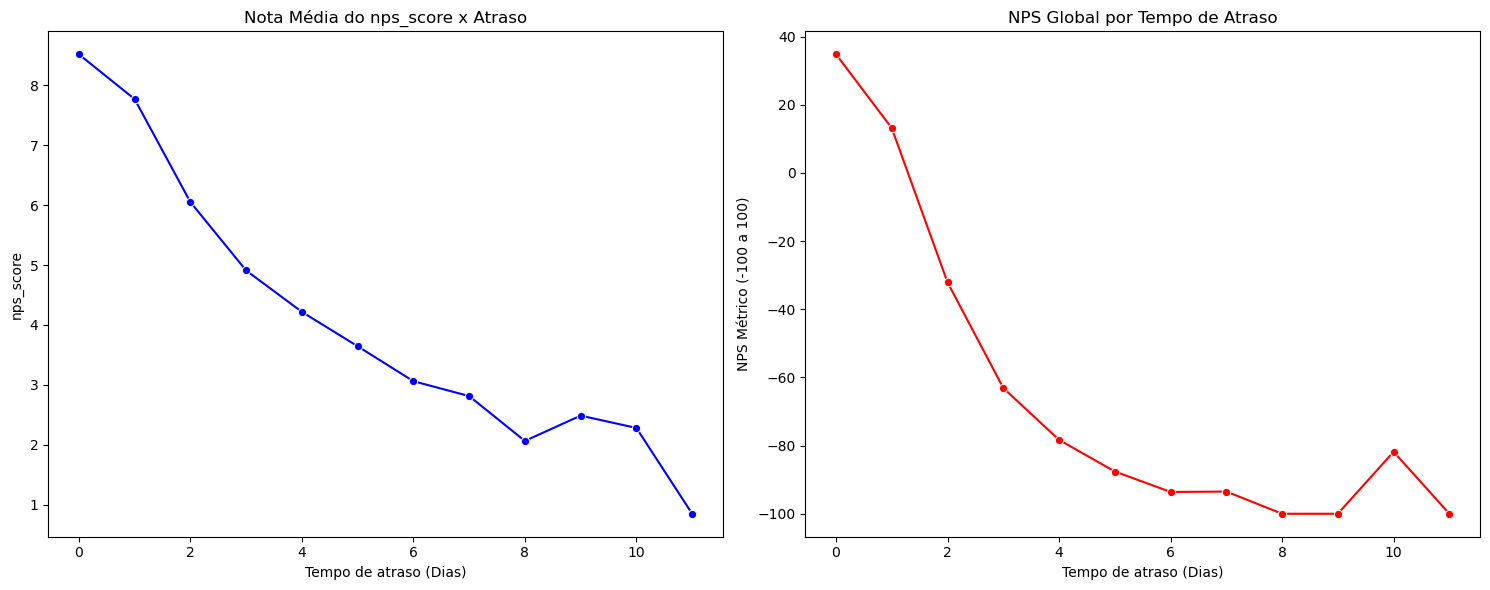

In [ ]:
# Cálculo das médias de nps_score em relação ao complaints_count
nps_score_media = df.groupby('complaints_count')['nps_score'].mean().reset_index()

# Cálculo do nota de NPS global em relação ao complaints_count
nps_global = df.groupby('complaints_count')['nps_score'].apply(calcula_nps).reset_index()

# Exibição lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# GRÁFICO 1: nps_score médio
sns.lineplot(
    data=nps_score_media, 
    x='complaints_count', 
    y='nps_score', 
    marker='o', 
    color='blue', 
    ax=axes[0]
)
axes[0].set_title('Nota Média do nps_score x Reclamações')
axes[0].set_xlabel('Reclamações')
axes[0].set_ylabel('nps_score')
axes[0].grid(True, alpha=0.0)

# GRÁFICO 2: NPS Global
sns.lineplot(
    data=nps_global, 
    x='complaints_count', 
    y='nps_score',
    marker='o', 
    color='red', 
    ax=axes[1]
)
axes[1].set_title('NPS Global x Reclamações')
axes[1].set_xlabel('Reclamações')
axes[1].set_ylabel('NPS Métrico (-100 a 100)')
axes[1].grid(True, alpha=0.0)

plt.tight_layout()
plt.show()

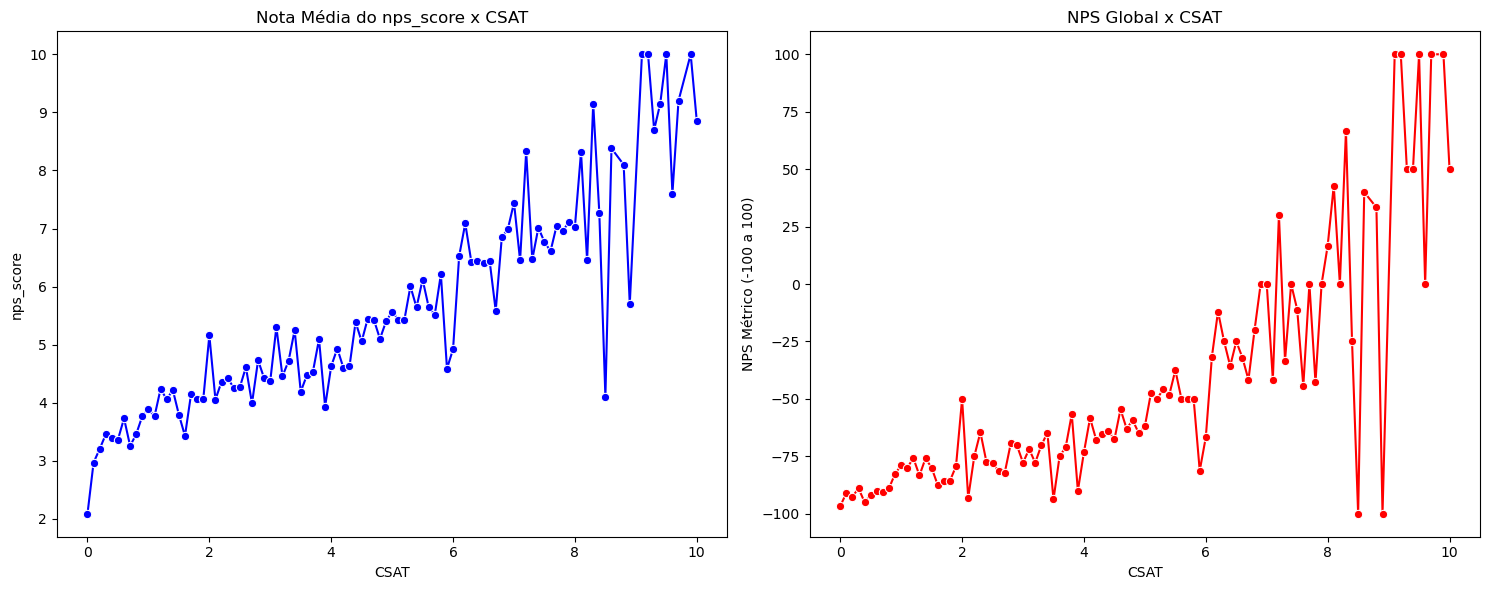

In [ ]:
# Cálculo das médias de nps_score em relação ao delivery_delay_days
nps_score_media = df.groupby('csat_internal_score')['nps_score'].mean().reset_index()

# Cálculo do nota de NPS global em relação ao delivery_delay_days
nps_global = df.groupby('csat_internal_score')['nps_score'].apply(calcula_nps).reset_index()

# Exibição lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# GRÁFICO 1: nps_score médio
sns.lineplot(
    data=nps_score_media, 
    x='csat_internal_score', 
    y='nps_score', 
    marker='o', 
    color='blue', 
    ax=axes[0]
)
axes[0].set_title('Nota Média do nps_score x CSAT')
axes[0].set_xlabel('CSAT')
axes[0].set_ylabel('nps_score')
axes[0].grid(True, alpha=0.0)

# GRÁFICO 2: NPS Global
sns.lineplot(
    data=nps_global, 
    x='csat_internal_score', 
    y='nps_score',
    marker='o', 
    color='red', 
    ax=axes[1]
)
axes[1].set_title('NPS Global x CSAT')
axes[1].set_xlabel('CSAT')
axes[1].set_ylabel('NPS Métrico (-100 a 100)')
axes[1].grid(True, alpha=0.0)

plt.tight_layout()
plt.show()

Analisando graficamente percebemos que ambas as variáveis possuem tendência de variação correlacionada ao nps_score. No entanto, no caso de csat_internal_score há um ruído que aumenta no intervalo de 8 a 10. Isso ocorre, provavelmente, devido ao n cair nessa zona de csat. Verificaremos o n das nossas segmentações, antes de realizar os testes de hipótese.

In [ ]:
df['faixa_reclamacoes'].value_counts()

faixa_reclamacoes
[2-4]     1384
[5-7]      879
[0-1]      145
[8-11]      92
Name: count, dtype: int64

In [ ]:
df['faixa_csat'].value_counts()

faixa_csat
[0-1]     996
[2-4]     941
[5-7]     514
[8-10]     49
Name: count, dtype: int64

De fato, nos dois casos as faixas com os maiores valores de CSAT e de reclamações possuem n mais baixos, sendo o CSAT entre 8 e 10 o mais baixo de todos. 

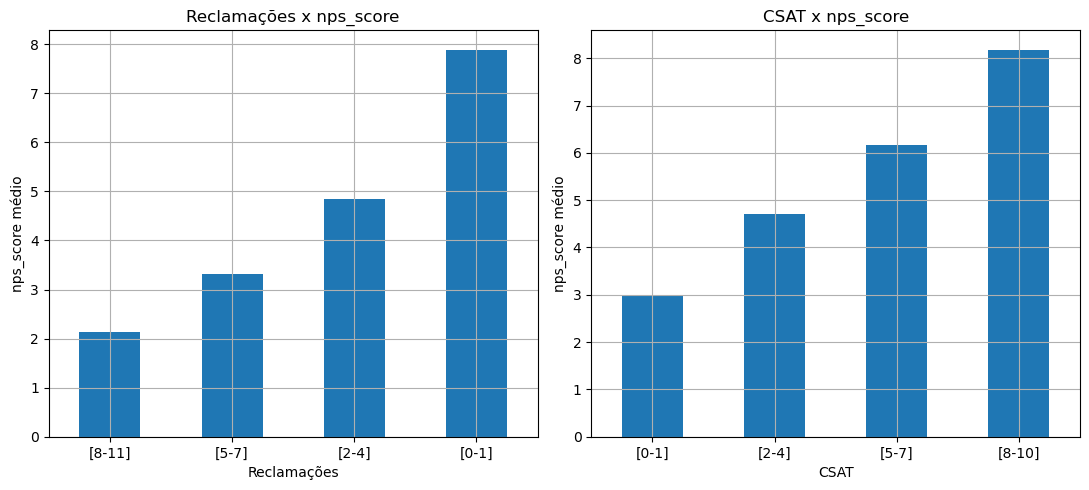

In [ ]:
# Grades do plot
fig, axs = plt.subplots(1, 2, figsize=(11, 5))

# Gráfico 1, contendo a média do nps_score com base na segmentação do número de reclamações
df.groupby('faixa_reclamacoes')['nps_score'].mean().sort_values(ascending=True).plot(kind='bar', ax = axs[0])
axs[0].set_title('Reclamações x nps_score')
axs[0].set_xlabel('Reclamações')
axs[0].set_ylabel('nps_score médio')
axs[0].grid(True)
axs[0].tick_params(axis='x', rotation=0)

# Gráfico 2, contendo a média do nps_score em função de CSAT
df.groupby('faixa_csat')['nps_score'].mean().sort_values(ascending=True).plot(kind='bar', ax = axs[1])
axs[1].set_title('CSAT x nps_score')
axs[1].set_xlabel('CSAT')
axs[1].set_ylabel('nps_score médio')
axs[1].grid(True)
axs[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

A tendência na variação do nps_score médio em função das reclamações e do CSAT são evidentes, visualmente. Para garantirmos a relevância estatística dessas tendências, iremos realizar os testes de hipótese. Como o n para os segmentos finais é mais baixo, principalmente em CSAT, não iremos utilizar a ANOVA com base no Teorema Central do Limite e passaremos a utilizar um método não paramétrico, chamado Kruskal-Wallis.

In [ ]:
nps_reclamacoes_0_1 = df[df['faixa_reclamacoes']=='[0-1]']['nps_score']
nps_reclamacoes_2_4 = df[df['faixa_reclamacoes']=='[2-4]']['nps_score']
nps_reclamacoes_5_7 = df[df['faixa_reclamacoes']=='[5-7]']['nps_score']
nps_reclamacoes_8_11 = df[df['faixa_reclamacoes']=='[8-11]']['nps_score']


stat_H, p_value = stats.kruskal(nps_reclamacoes_0_1, nps_reclamacoes_2_4, nps_reclamacoes_5_7, nps_reclamacoes_8_11)
print('stat_H: ',stat_H)
print('p-valor: ', p_value)

stat_H:  540.6655182661464
p-valor:  7.331281086918664e-117


In [ ]:
nps_csat_0_1 = df[df['faixa_csat']=='[0-1]']['nps_score']
nps_csat_2_4 = df[df['faixa_csat']=='[2-4]']['nps_score']
nps_csat_5_7 = df[df['faixa_csat']=='[5-7]']['nps_score']
nps_csat_8_10 = df[df['faixa_csat']=='[8-10]']['nps_score']


stat_H, p_value = stats.kruskal(nps_csat_0_1, nps_csat_2_4, nps_csat_5_7, nps_csat_8_10)
print('stat_H: ',stat_H)
print('p-valor: ', p_value)

stat_H:  684.4751789876359
p-valor:  4.879276218803451e-148


Ambos os testes apresentaram p-valor extremamente abaixo de 0,05. Isso indica que as variações de csat e do número de reclamações provoca variações estatisticamente relevantes no nps_score. Estes dados corroboram os valores encontrados na matriz de correlação e nos padrões gráficos apresentados.